
Model Evaluation:
Mean Squared Error: 26.782523432700017
R2 Score: 0.6347860115964858


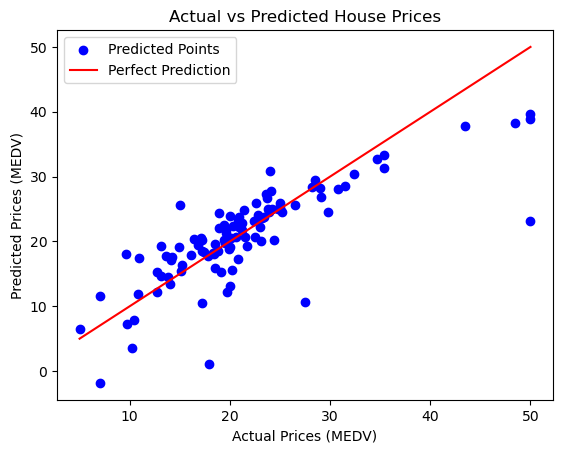


Coefficients: [ 4.7768173  -0.59349623 -0.94868975  0.06578322 -8.65012257  0.03227307]
Intercept: 19.2769645334139


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

data = pd.read_csv("Boston.csv")

data.columns = data.columns.str.strip().str.upper()

if 'UNNAMED: 0' in data.columns:
    data = data.drop(columns=['UNNAMED: 0'])

features = ['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'NOX', 'AGE']

data = data.dropna(subset=features + ['MEDV'])

X = data[features].values
y = data['MEDV'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel Evaluation:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

plt.figure()

plt.scatter(y_test, y_pred, color='blue', label='Predicted Points')

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red', label='Perfect Prediction')

plt.xlabel("Actual Prices (MEDV)")
plt.ylabel("Predicted Prices (MEDV)")
plt.title("Actual vs Predicted House Prices")
plt.legend()

plt.show()

print("\nCoefficients:", model.coef_)
print("Intercept:", model.intercept_)